In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
df = pd.read_csv("CKD_preprocessed_patient_level.csv")
TARGET = "CKD (1-yes, 0-no)"


In [2]:
# Validation guards
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

if "Patient ID" in df.columns:
    raise ValueError(
        "Patient ID is still present. Remove Patient ID before modeling."
    )
if df.isnull().sum().sum() > 0:
    raise ValueError("Missing values detected in the dataset.")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy    = accuracy_score(y_test, y_pred)
precision   = precision_score(y_test, y_pred, zero_division=0)
recall      = recall_score(y_test, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1          = f1_score(y_test, y_pred, zero_division=0)
roc_auc     = roc_auc_score(y_test, y_prob)
pr_auc      = average_precision_score(y_test, y_prob)

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["No CKD", "CKD"], zero_division=0))



Training samples: 280
Testing samples : 120

LOGISTIC REGRESSION RESULTS
Accuracy    : 0.6667
Precision   : 0.6364
Recall      : 0.6364
Specificity : 0.6923
F1 Score    : 0.6364
ROC-AUC     : 0.7069
PR-AUC      : 0.6669

Confusion Matrix:
[[45 20]
 [20 35]]

Classification Report:
              precision    recall  f1-score   support

      No CKD       0.69      0.69      0.69        65
         CKD       0.64      0.64      0.64        55

    accuracy                           0.67       120
   macro avg       0.66      0.66      0.66       120
weighted avg       0.67      0.67      0.67       120



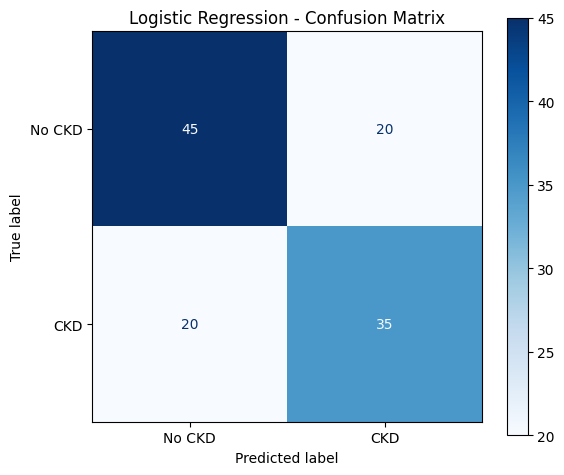

In [3]:
# Confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No CKD", "CKD"],
    cmap="Blues", values_format="d", ax=ax
)
ax.set_title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()




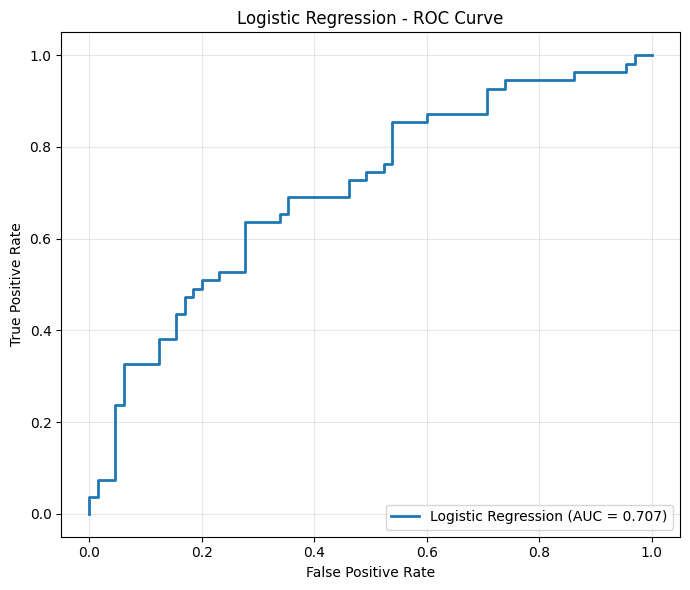

In [4]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Logistic Regression - ROC Curve")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


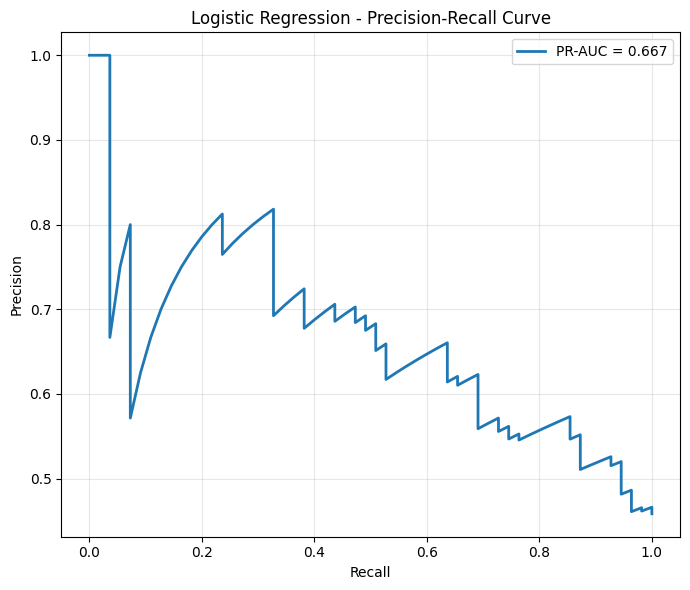

In [5]:
#  Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curve, precision_curve, linewidth=2,
        label=f"PR-AUC = {pr_auc:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Logistic Regression - Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()




Top 12 coefficients by absolute magnitude:
                                    Feature  Coefficient  Absolute_Coefficient
                         BMI_x_Hypertension    -0.683816              0.683816
                Diabetic_Duration_x_Insulin     0.506816              0.506816
                                Height (cm)    -0.506260              0.506260
                  Gender (M-male, F-female)     0.444196              0.444196
                  Pain killer (1-yes, 0-no)     0.428855              0.428855
               Walk Regularly (1-yes, 0-no)     0.360875              0.360875
                          Comorbidity_Count     0.330409              0.330409
                 Hypertension (1-yes, 0-no)     0.307889              0.307889
       Sleep (1-sufficient, 0-insufficient)    -0.254150              0.254150
Family Background of Diabetes (1-yes, 0-no)     0.219195              0.219195
                     Weight_Change_From_Avg    -0.193501              0.193501
        

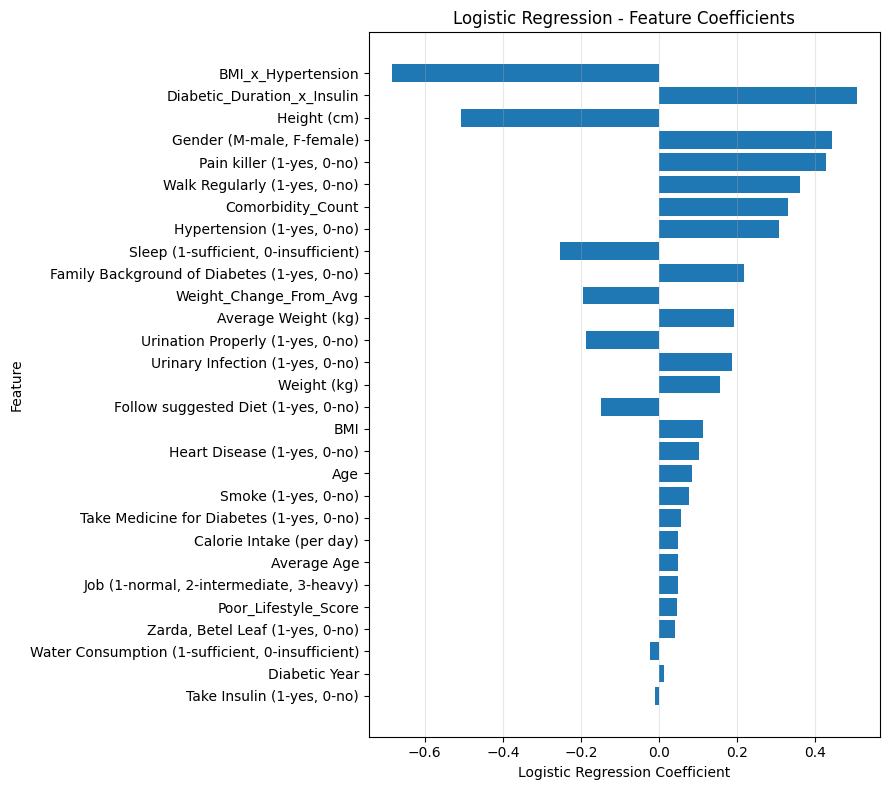

In [6]:
# STANDARDIZED COEFFICIENTS
classifier = model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": classifier.coef_[0]
})
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

print("\nTop 12 coefficients by absolute magnitude:")
print(
    coefficients
    .sort_values("Absolute_Coefficient", ascending=False)
    .head(12)
    .to_string(index=False)
)
plot_df = coefficients.sort_values("Absolute_Coefficient", ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df["Feature"], plot_df["Coefficient"])
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_ylabel("Feature")
ax.set_title("Logistic Regression - Feature Coefficients")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()